# Regression Trees: Quality & Commercial Score

Trains a `DecisionTreeRegressor` for each target. No feature scaling needed.
Saves the fitted models and results to `results/`.

## About Decision Trees

A decision tree predicts by asking a series of yes/no questions about a game's features, like a flowchart. "Is the complexity above 3?" If yes, go left; if no, go right. "Does it have worker placement?" Left or right again. After a chain of these questions, you land on a final prediction: the average score of all training games that answered the same way. The tree learns which questions to ask and where to set the thresholds by looking at the training data and finding the splits that group similar scores together. It's easy to understand and interpret, but a single tree can be fragile: small changes in the data can produce a completely different tree.

![Decision Tree](../assets/diagram_decision_tree.png)

## Constants

In [1]:
# ── Constants ──────────────────────────────────────────────────────────────
import os

# How much data goes to training vs. testing.
# Default is 80/20: the model learns from 80% of games (~17,500) and we test
# on the remaining 20% (~4,400). We also run every notebook at 50/50, 70/30,
# and 90/10 to check that results stay consistent (see results/*.md).
# Configurable via environment variable so the run-notebooks script can sweep
# through all splits automatically.
TRAIN_RATIO = float(os.environ.get("LUDOMETRICS_TRAIN_RATIO", "0.80"))
TEST_RATIO = round(1.0 - TRAIN_RATIO, 10)

# Fixed seed so every run produces identical results.
# Without this, the random train/test split would change each time,
# making it impossible to compare models fairly.
RANDOM_STATE = 42

# How many levels of yes/no questions the tree can ask.
# A decision tree works by splitting data: "is playtime > 60 min?" → yes/no,
# then "is complexity > 3?" → yes/no, and so on. Each split adds a level.
# Depth 10 means at most 10 questions in a row before making a prediction.
# Too deep (unlimited) and the tree memorises the training data instead of
# learning general patterns. Too shallow (3–5) and it can't capture enough
# detail. 10 is a common starting point for datasets with hundreds of features.
MAX_DEPTH = 10

SPLIT_LABEL = f"{int(TRAIN_RATIO * 100)}_{int(TEST_RATIO * 100)}"
SPLIT_DISPLAY = f"{int(TRAIN_RATIO * 100)}/{int(TEST_RATIO * 100)}"

## Prepare data

In [2]:
import sys
import time

sys.path.insert(0, "..")

import joblib
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

from utils.train_utils import update_results_table

df = pd.read_csv("../data/games_processed.csv")
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

EXCLUDE_HERO_GAMES = [13, 171, 181, 188, 320, 822, 1294, 1406, 2223, 2243, 2397, 2425, 50381]
# Catan, Chess, Risk, Go, Scrabble, Carcassonne, Clue, Monopoly,
# UNO, Yahtzee, Backgammon, Battleship, Cards Against Humanity
hero_mask = df['BGGId'].isin(EXCLUDE_HERO_GAMES)
hero_df = df[hero_mask].copy()
df = df[~hero_mask].copy()
print(f"Held out {hero_mask.sum()} hero games; {len(df):,} rows remain")

DROP_COLS = ["BGGId", "quality_score", "commercial_score"]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
TARGETS = ["quality_score", "commercial_score"]

X = df[FEATURE_COLS]
print(f"Features: {len(FEATURE_COLS)} columns")

X_train, X_test = train_test_split(X, test_size=TEST_RATIO, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Loaded 21,925 rows × 403 columns
Held out 13 hero games; 21,912 rows remain
Features: 400 columns
Train: 10,956  |  Test: 10,956


## Train one model per target

For each target score, we give the tree all 17,500 training games and let it figure out the best sequence of yes/no questions. At each step, the tree picks the feature and threshold that best separates high-scoring games from low-scoring ones, for example "is complexity above 2.8?" It keeps splitting until it reaches our depth limit of 10 levels. After training, we can see how complex the tree ended up: how many levels deep it goes and how many final prediction groups (leaves) it created.

A tree of depth 10 can have at most 1,024 leaves (2 ^ 10 = 1,024), but ours ends up with fewer because many branches get cut short when splitting further didn't help separate scores. Each game follows just one path through the tree, answering at most 10 yes/no questions to land on one of those groups.

In [3]:
results = {}

for target in TARGETS:
    y_train = df.loc[X_train.index, target]

    model = DecisionTreeRegressor(max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
    t0 = time.monotonic()
    model.fit(X_train, y_train)
    elapsed = time.monotonic() - t0

    results[target] = {"model": model, "elapsed": elapsed}
    print(f"{target:20s}  trained in {elapsed:.1f}s")

# Show the tree structure for each target
for target in TARGETS:
    tree = results[target]["model"]
    max_possible = 2 ** tree.get_depth()
    print(f"\n{target} tree structure:")
    print(f"  Depth:  {tree.get_depth()} levels of questions")
    print(f"  Leaves: {tree.get_n_leaves()} prediction groups (out of {max_possible:,} possible at depth {tree.get_depth()})")

quality_score         trained in 0.1s


commercial_score      trained in 0.1s

quality_score tree structure:
  Depth:  10 levels of questions
  Leaves: 311 prediction groups (out of 1,024 possible at depth 10)

commercial_score tree structure:
  Depth:  10 levels of questions
  Leaves: 367 prediction groups (out of 1,024 possible at depth 10)


## Evaluate

To make a prediction, the tree runs a new game through its chain of yes/no questions until it lands on a leaf. We start with a single well-known game to see the tree in action, then measure how accurate the predictions are across all 4,400 test games.

Both quality_score and commercial_score are on a 0–100 scale, where 0 is the lowest-rated or least-owned game in the dataset and 100 is the highest. So when we say the model is "off by 3," that means 3 out of 100, a 3% error on the full range.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

# Load game names for readable output
game_names = pd.read_csv("../dataset/games.csv", usecols=["BGGId", "Name"]).set_index("BGGId")["Name"]

# Pick the highest-rated game in the test set as our example
example_idx = df.loc[X_test.index, "quality_score"].idxmax()
example_row = X_test.loc[[example_idx]]
example_id = df.loc[example_idx, "BGGId"]
example_name = game_names.get(example_id, f"BGGId {example_id}")

print(f"Example prediction ({example_name}):")
for target in TARGETS:
    model = results[target]["model"]
    pred = model.predict(example_row)[0]
    actual = df.loc[example_idx, target]
    print(f"  Predicted {target}: {pred:.1f}")
    print(f"  Actual    {target}: {actual:.1f}")
print()

# Generate predictions for all test games — used by the evaluation cells below
for target in TARGETS:
    y_actual = df.loc[X_test.index, target]
    model = results[target]["model"]
    y_predicted = model.predict(X_test)
    results[target]["y_predicted"] = y_predicted
    results[target]["y_actual"] = y_actual

Example prediction (Gloomhaven):
  Predicted quality_score: 77.9
  Actual    quality_score: 85.1
  Predicted commercial_score: 91.4
  Actual    commercial_score: 94.3



### How far off are the predictions? (RMSE and MAE)

quality_score
  MAE:  predictions are typically off by 1.6 on a 0–100 scale
  RMSE: accounting for large misses, the average error rises to 2.9



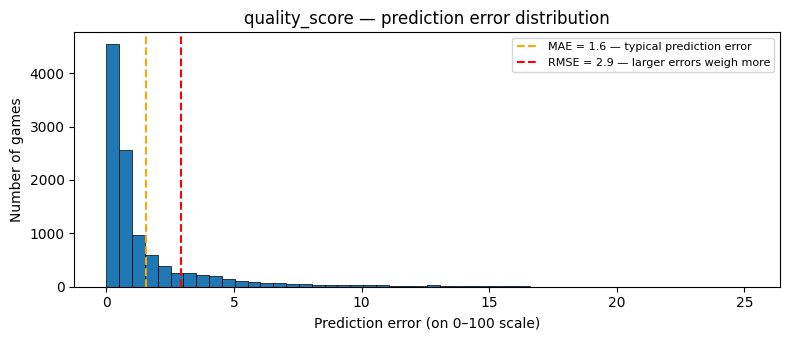

commercial_score
  MAE:  predictions are typically off by 8.2 on a 0–100 scale
  RMSE: accounting for large misses, the average error rises to 10.7



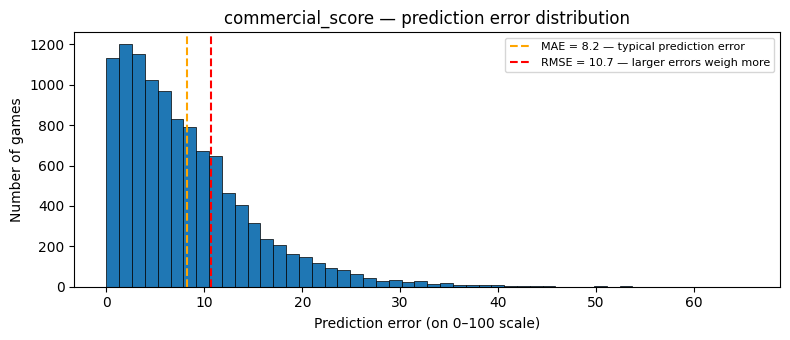

In [5]:
for target in TARGETS:
    y_actual = results[target]["y_actual"]
    y_predicted = results[target]["y_predicted"]
    abs_errors = np.abs(y_actual.values - y_predicted)

    mae = mean_absolute_error(y_actual, y_predicted)
    rmse = mean_squared_error(y_actual, y_predicted) ** 0.5
    results[target]["rmse"] = rmse
    results[target]["mae"] = mae

    print(f"{target}")
    print(f"  MAE:  predictions are typically off by {mae:.1f} on a 0–100 scale")
    print(f"  RMSE: accounting for large misses, the average error rises to {rmse:.1f}")
    print()

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(abs_errors, bins=50, edgecolor="black", linewidth=0.5)
    ax.axvline(mae, color="orange", linestyle="--", linewidth=1.5,
               label=f"MAE = {mae:.1f} — typical prediction error")
    ax.axvline(rmse, color="red", linestyle="--", linewidth=1.5,
               label=f"RMSE = {rmse:.1f} — larger errors weigh more")
    ax.set_xlabel("Prediction error (on 0–100 scale)")
    ax.set_ylabel("Number of games")
    ax.set_title(f"{target} — prediction error distribution")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

Both RMSE and MAE measure how far off the predictions are, but they weight errors differently. **MAE** (Mean Absolute Error) is the plain average of all prediction errors. It treats a 1-point miss and a 10-point miss as equally important when computing the average. **RMSE** (Root Mean Squared Error) squares each error before averaging, which makes large misses count for much more than small ones. That's why RMSE is always at least as large as MAE.

Most games in the histogram pile up near zero, and the model gets them nearly right. The long tail stretching to the right is the small number of games the model struggles with. MAE averages everything equally, so that tail barely moves the number. RMSE squares those tail errors first, so they inflate the average much more, which is why the red RMSE line sits further right than the orange MAE line.

### How spread out are the errors? (percentiles)

quality_score
  25th percentile: 0.28 pts — 1 in 4 predictions are this close or better
  50th percentile: 0.65 pts — the typical miss
  75th percentile: 1.61 pts — 3 in 4 predictions are within this range
  90th percentile: 4.15 pts — only 10% of predictions miss by more than this



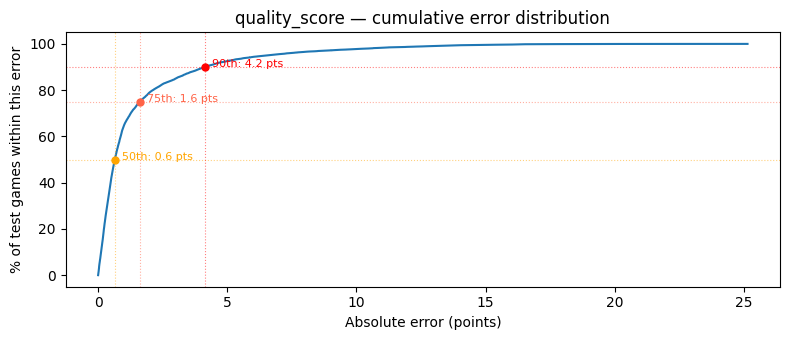

commercial_score
  25th percentile: 3.10 pts — 1 in 4 predictions are this close or better
  50th percentile: 6.55 pts — the typical miss
  75th percentile: 11.37 pts — 3 in 4 predictions are within this range
  90th percentile: 17.15 pts — only 10% of predictions miss by more than this



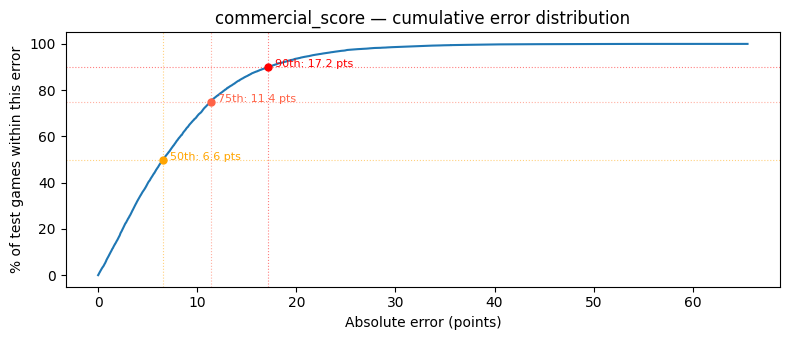

In [6]:
for target in TARGETS:
    y_actual = results[target]["y_actual"]
    y_predicted = results[target]["y_predicted"]
    abs_errors = np.sort(np.abs(y_actual.values - y_predicted))

    p25, p50, p75, p90 = np.percentile(abs_errors, [25, 50, 75, 90])
    print(f"{target}")
    print(f"  25th percentile: {p25:.2f} pts — 1 in 4 predictions are this close or better")
    print(f"  50th percentile: {p50:.2f} pts — the typical miss")
    print(f"  75th percentile: {p75:.2f} pts — 3 in 4 predictions are within this range")
    print(f"  90th percentile: {p90:.2f} pts — only 10% of predictions miss by more than this")
    print()

    cumulative_pct = np.arange(1, len(abs_errors) + 1) / len(abs_errors) * 100

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(abs_errors, cumulative_pct, linewidth=1.5)
    for pct, val, color in [(50, p50, "orange"), (75, p75, "tomato"), (90, p90, "red")]:
        ax.axhline(pct, color=color, linestyle=":", linewidth=0.8, alpha=0.5)
        ax.axvline(val, color=color, linestyle=":", linewidth=0.8, alpha=0.5)
        ax.plot(val, pct, "o", color=color, markersize=5)
        ax.annotate(f"  {pct}th: {val:.1f} pts", (val, pct), fontsize=8, color=color)
    ax.set_xlabel("Absolute error (points)")
    ax.set_ylabel("% of test games within this error")
    ax.set_title(f"{target} — cumulative error distribution")
    fig.tight_layout()
    plt.show()

An average doesn't tell you whether most predictions are close with a few wild misses, or everything is moderately off. Error percentiles break this down: the 50th percentile is the "typical" miss (half of games are predicted better than this), while the 90th percentile shows how bad the worst 10% get.

The curve reads like this: pick a point on the x-axis (say, 3.0), follow it up to the curve, then read across to the y-axis — that tells you what percentage of test games were predicted within 3 points of their actual score. A curve that shoots up steeply on the left means most predictions are very close; a long tail stretching right means some games are much harder to predict than others.

### Does the model explain the scores? (R² and residuals)

quality_score         R² = 0.3674


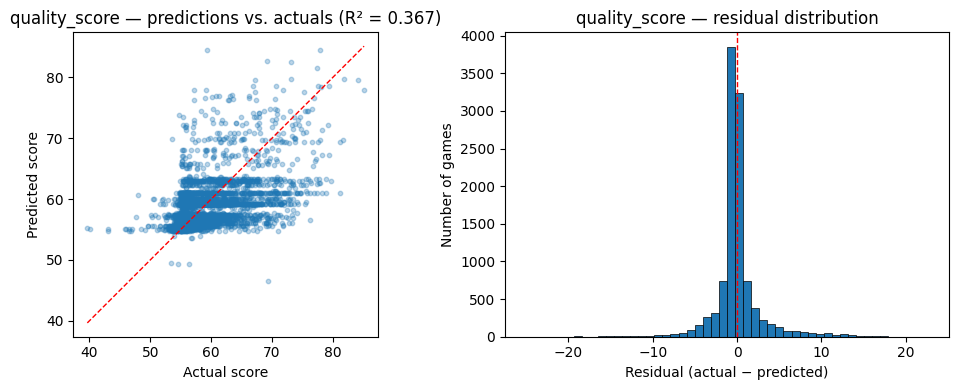

commercial_score      R² = 0.4118


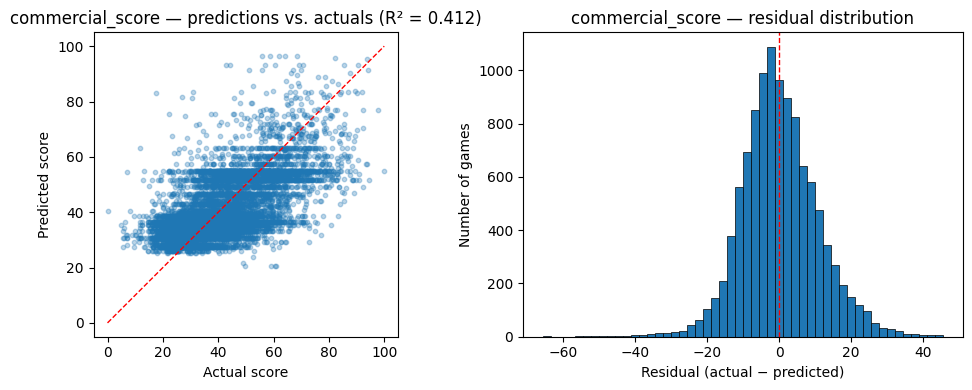

In [7]:
for target in TARGETS:
    y_actual = results[target]["y_actual"]
    y_predicted = results[target]["y_predicted"]
    r2 = r2_score(y_actual, y_predicted)
    results[target]["r2"] = r2
    residuals = y_actual.values - y_predicted

    print(f"{target:20s}  R² = {r2:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].scatter(y_actual, y_predicted, alpha=0.3, s=10)
    lo = min(y_actual.min(), y_predicted.min())
    hi = max(y_actual.max(), y_predicted.max())
    axes[0].plot([lo, hi], [lo, hi], "r--", linewidth=1)
    axes[0].set_xlabel("Actual score")
    axes[0].set_ylabel("Predicted score")
    axes[0].set_title(f"{target} — predictions vs. actuals (R² = {r2:.3f})")
    axes[0].set_aspect("equal", adjustable="box")

    axes[1].hist(residuals, bins=50, edgecolor="black", linewidth=0.5)
    axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
    axes[1].set_xlabel("Residual (actual − predicted)")
    axes[1].set_ylabel("Number of games")
    axes[1].set_title(f"{target} — residual distribution")

    fig.tight_layout()
    plt.show()

On the scatter plot, each dot is one test game: its actual score on the x-axis, the model's prediction on the y-axis. If the model were perfect, every dot would sit exactly on the red diagonal line, where predicted equals actual. The more the dots scatter away from that line, the lower the R². An R² of 1.0 means every dot is on the line; an R² of 0.0 means the model's predictions are no better than just guessing the average score for every game.

The dots here form a wide cloud because a depth-10 tree can only ask 10 yes/no questions before making a prediction. All games that answer those 10 questions the same way land in the same leaf and get the same predicted score, even if their actual scores are quite different. You can see this as horizontal bands of dots at the same predicted value: those are groups of games stuck in one leaf. If telling two games apart requires an 11th question the tree can't ask, they get the same prediction regardless.

The **residual histogram** shows prediction errors (actual minus predicted). If the model is unbiased, this should be centred on zero, with roughly as many over-predictions as under-predictions. A histogram that leans to one side would mean the model systematically guesses too high or too low.

## Save results

In [8]:
MODEL_DIR = Path("../results/models/regression_trees")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

for target in TARGETS:
    out_path = MODEL_DIR / f"{target}_{SPLIT_LABEL}.pkl"
    joblib.dump(results[target]["model"], out_path)
    print(f"Saved {out_path}")

    predictions = pd.DataFrame({
        "BGGId": df.loc[X_test.index, "BGGId"].values,
        "actual": results[target]["y_actual"].values,
        "predicted": results[target]["y_predicted"],
    })
    pred_path = MODEL_DIR / f"{target}_{SPLIT_LABEL}_predictions.csv"
    predictions.to_csv(pred_path, index=False)
    print(f"Saved {pred_path}")

RESULTS_DIR = Path("../results")

for target in TARGETS:
    elapsed = results[target]["elapsed"]
    minutes, seconds = divmod(elapsed, 60)
    time_label = (
        f"{int(minutes)}m {seconds:.1f}s" if minutes >= 1 else f"{seconds:.1f}s"
    )
    update_results_table(
        RESULTS_DIR / f"{target}.md",
        algorithm="Regression Trees (DecisionTreeRegressor)",
        split=SPLIT_DISPLAY,
        train_size=len(X_train),
        test_size=len(X_test),
        training_time=time_label,
        rmse=results[target]["rmse"],
        r2=results[target]["r2"],
    )
    print(f"Updated results/{target}.md")

Saved ../results/models/regression_trees/quality_score_50_50.pkl
Saved ../results/models/regression_trees/quality_score_50_50_predictions.csv
Saved ../results/models/regression_trees/commercial_score_50_50.pkl


Saved ../results/models/regression_trees/commercial_score_50_50_predictions.csv


Updated results/quality_score.md


Updated results/commercial_score.md
